# Coarse-to-Fine Breast Lesion Segmentation in Ultrasound Images: A Detection-Guided Two-Stage Framework - Evaluation Pipeline

In [ ]:
%matplotlib inline

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import albumentations as A
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import segmentation_models_pytorch as smp
from scipy.spatial import cKDTree
from skimage.filters import threshold_otsu
from torch.utils.data import DataLoader, Dataset as BaseDataset
from ultralytics import YOLO

In [12]:
# ── PATH CONFIGURATION ──────────────────────────────────────────────────────
BASE_DIR = './'
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODELS_DIR = os.path.join(BASE_DIR, 'weights')


print('DATA_DIR  :', DATA_DIR)
print('MODELS_DIR:', MODELS_DIR)

DATA_DIR  : ./data
MODELS_DIR: ./weights


In [13]:
# ── PIPELINE CONFIGURATION ──────────────────────────────────────────────────

# Dataset
datasrcs      = "BUSI"               # UDIAT | BUSI | BUSBRAr
datasrcs_crop = f"{datasrcs}_crop"

img_ext       = ".png"
mask_ext      = ".png" 
mask_suffix   = ""                    
gt_img_prefix = "bus_"                # "bus_"  for BUSBRAr, empty otherwise
gt_msk_prefix = "mask_"               # "mask_" for BUSBRAr, empty otherwise

# Segmentation model
method      = "Unet"                  # Unet | UnetPlusPlus | DeepLabV3Plus
backbone    = "resnet18"              
OUT_CLASSES = 1

# YOLO
YOLO_MODEL = "yolov8s"               # yolov3-tinyu | yolov8s | yolo12s | 
YOLO_CONF  = 0.15                     # detection confidence threshold 0.15
YOLO_IOU   = 0.45                     # NMS IoU threshold 0.45

# Derived paths — best checkpoints saved by ModelCheckpoint during training
seg_crop_weights_path = os.path.join(MODELS_DIR, "best__{}__{}__{}.ckpt".format(method, backbone, datasrcs_crop))
seg_weights_path      = os.path.join(MODELS_DIR, "best__{}__{}__{}.ckpt".format(method, backbone, datasrcs))
yolo_weights_path     = os.path.join(MODELS_DIR, "best__{}__{}.pt".format(YOLO_MODEL, datasrcs))

print(f"Seg crop weights : {seg_crop_weights_path}")
print(f"Seg weights      : {seg_weights_path}")
print(f"YOLO weights     : {yolo_weights_path}")
print(f"Seg crop weights exist : {os.path.exists(seg_crop_weights_path)}")
print(f"Seg weights exist      : {os.path.exists(seg_weights_path)}")
print(f"YOLO weights exist     : {os.path.exists(yolo_weights_path)}")

Seg crop weights : ./weights/best__Unet__resnet18__BUSI_crop.ckpt
Seg weights      : ./weights/best__Unet__resnet18__BUSI.ckpt
YOLO weights     : ./weights/best__yolov8s__BUSI.pt
Seg crop weights exist : True
Seg weights exist      : True
YOLO weights exist     : True


In [14]:
def read_file_to_list(file_path: str) -> list[str]:
    try:
        with open(file_path) as fh:
            return fh.read().splitlines()
    except FileNotFoundError:
        print(f"Error: file not found — {file_path}")
        return []


def get_validation_augmentation(img_size: int = 512) -> A.Compose:
    return A.Compose([A.Resize(height=img_size, width=img_size)])


def otsu_threshold(prob_map: np.ndarray) -> np.ndarray:
    """Binarise *prob_map* using Otsu's method.

    Falls back to 0.5 when the map is flat (all values identical),
    which would cause threshold_otsu to raise a ValueError.
    """
    thresh = threshold_otsu(prob_map) if prob_map.min() != prob_map.max() else 0.5
    return (prob_map > thresh).astype(np.uint8)

In [15]:
def convert_bn_to_gn(module: nn.Module, max_groups: int = 32) -> None:
    """Recursively replace every BatchNorm2d in *module* with GroupNorm.

    Mirrors the training notebook exactly.
    """
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            num_channels = child.num_features
            num_groups   = next(
                g for g in range(max_groups, 0, -1)
                if num_channels % g == 0
            )
            setattr(module, name, nn.GroupNorm(num_groups, num_channels))
        else:
            convert_bn_to_gn(child, max_groups)

In [16]:
class SegmentationModel(pl.LightningModule):
    """Inference-time wrapper — mirrors the training notebook exactly."""

    def __init__(self, arch: str, encoder_name: str, in_channels: int, out_classes: int, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )
        # Replace BN with GroupNorm for DeepLabV3+ — must match training notebook
        if arch == "DeepLabV3Plus":
            convert_bn_to_gn(self.model)

        # Register ImageNet normalisation constants as non-trainable buffers
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        return self.model((image - self.mean) / self.std)

In [ ]:
# ── Load segmentation model (full image — fallback for missed detections) ────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seg_model = SegmentationModel(method, backbone, in_channels=3, out_classes=OUT_CLASSES)
ckpt = torch.load(seg_weights_path, weights_only=True, map_location=device)
seg_model.load_state_dict(ckpt["state_dict"] if "state_dict" in ckpt else ckpt)
seg_model.eval()
seg_model = seg_model.to(device)
print(f"Full-image seg model loaded on {device}: {method} | {datasrcs}")

# ── Load segmentation model (crop — used when YOLO detects) ─────────────────
seg_crop_model = SegmentationModel(method, backbone, in_channels=3, out_classes=OUT_CLASSES)
ckpt = torch.load(seg_crop_weights_path, weights_only=True, map_location=device)
seg_crop_model.load_state_dict(ckpt["state_dict"] if "state_dict" in ckpt else ckpt)
seg_crop_model.eval()
seg_crop_model = seg_crop_model.to(device)
print(f"Crop seg model loaded on {device}: {method} | {datasrcs_crop}")

# ── Load YOLO model ──────────────────────────────────────────────────────────
yolo_model = YOLO(yolo_weights_path)
print(f"YOLO model loaded: {YOLO_MODEL}")

print(f"\nWeights exist check:")
print(f"  seg (full)  : {os.path.exists(seg_weights_path)}")
print(f"  seg (crop)  : {os.path.exists(seg_crop_weights_path)}")
print(f"  YOLO        : {os.path.exists(yolo_weights_path)}")

Full-image seg model loaded on cpu: Unet | BUSI
Crop seg model loaded on cpu: Unet | BUSI_crop
YOLO model loaded: yolov8s

Weights exist check:
  seg (full)  : True
  seg (crop)  : True
  YOLO        : True


## Visualization

/var/folders/gj/lptfwr391rdf169q8g43fdm00000gp/T/ipykernel_38596/1610642835.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


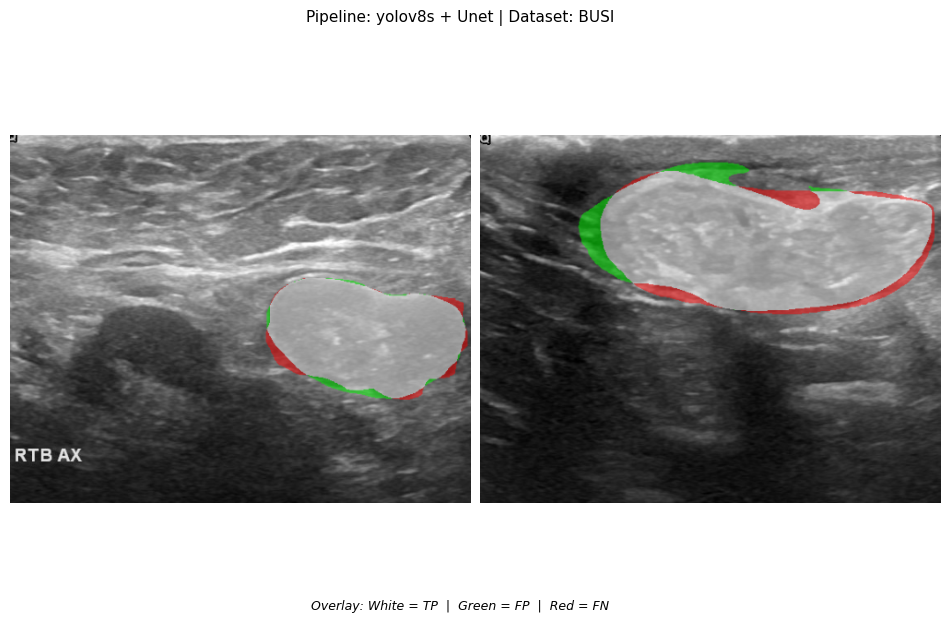

In [ ]:
# ── overlay visualization ───────────
from glob import glob
from pathlib import Path

aug = get_validation_augmentation()
img_dir = os.path.join(DATA_DIR, datasrcs, 'imgs')
gt_dir = os.path.join(DATA_DIR, datasrcs, 'gts')

GAP        = 0.02   # fractional gap between subplots
overlays = []   # collect overlay images and per-image info

image_ids = [Path(f).stem for f in glob("{}/*.*".format(img_dir))]
N_SAMPLES  = len(image_ids)

for img_id in image_ids:
    img_path = os.path.join(img_dir, img_id + img_ext)
    gt_path  = os.path.join(gt_dir, img_id + mask_ext)
    # ── Re-run pipeline ───────────────────────────────────────────────────────
    full_img        = cv2.imread(img_path)
    orig_H, orig_W  = full_img.shape[:2]
    results         = yolo_model.predict(img_path, conf=YOLO_CONF, iou=YOLO_IOU, verbose=False)
    best_box        = results[0].boxes[results[0].boxes.conf.argmax()]
    x1, y1, x2, y2 = map(int, best_box.xyxy[0].tolist())
    x1, y1         = max(0, x1), max(0, y1)
    x2, y2         = min(orig_W, x2), min(orig_H, y2)

    crop_img        = cv2.cvtColor(full_img[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)
    s               = aug(image=crop_img, mask=np.zeros((*crop_img.shape[:2], 1), dtype=np.float32))
    inp             = torch.tensor(s['image'].transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pr_crop = seg_crop_model(inp).sigmoid().squeeze().cpu().numpy()
    pr_crop = otsu_threshold(pr_crop)
    pr_crop_resized = cv2.resize(pr_crop, (x2-x1, y2-y1), interpolation=cv2.INTER_NEAREST)
    pr_full         = np.zeros((orig_H, orig_W), dtype=np.uint8)
    pr_full[y1:y2, x1:x2] = pr_crop_resized

    gt_full     = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    gt_full     = (gt_full > 0).astype(np.uint8)
    img_display = cv2.cvtColor(full_img, cv2.COLOR_BGR2RGB)

    # ── Build overlay ─────────────────────────────────────────────────────────
    overlay = img_display.copy()
    alpha   = 0.5
    tp_mask = (gt_full == 1) & (pr_full == 1)
    fp_mask = (gt_full == 0) & (pr_full == 1)
    fn_mask = (gt_full == 1) & (pr_full == 0)
    for mask, color in [(tp_mask, (255,255,255)), (fp_mask, (0,255,0)), (fn_mask, (255,0,0))]:
        overlay[mask] = (alpha * np.array(color) + (1-alpha) * img_display[mask]).astype(np.uint8)

    # ── Collect metrics ───────────────────────────────────────────────────────
    overlays.append({
        'image':   overlay,
        'stem':    img_id,
    })

# ── Resize all overlays to the same fixed size ───────────────────────────────
TARGET_H, TARGET_W = 400, 500   # pixels — adjust to taste
for entry in overlays:
    entry['image'] = cv2.resize(
        entry['image'], (TARGET_W, TARGET_H), interpolation=cv2.INTER_LINEAR
    )

# ── Build single figure with overlays side by side ─────────────────────────
fig, axes = plt.subplots(
    1, N_SAMPLES,
    figsize=(6 * N_SAMPLES, 6),
    gridspec_kw={'wspace': GAP}
)

for ax, entry in zip(axes, overlays):
    ax.imshow(entry['image'])
    ax.axis('off')

# small shared legend below the figure
fig.text(0.5, 0.01,
         'Overlay: White = TP  |  Green = FP  |  Red = FN',
         ha='center', fontsize=9, style='italic')

plt.suptitle(
    f'Pipeline: {YOLO_MODEL} + {method} | Dataset: {datasrcs}',
    fontsize=11, y=1.01
)

plt.tight_layout()
